In [61]:
# Производим импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Загружаем датасет
df = pd.read_csv('synthetic_regression.csv')

In [ ]:
# Разбеваем датасет на массив призноков 'X' и целевую переменную 'y'
X = df.drop(columns='target').values
y = df['target'].values

In [17]:
# Отделяем тестувую выборку (20%)
X_temp, X_test, y_temp, y_test  = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Разбиваем оставшиеся данные для обучения (80%) и для валидации (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

In [19]:
# Выводим информацию о данных
print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train shape:     X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation shape: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test shape:      X = {X_test.shape}, y = {y_test.shape}") 

Train size: 128, Val size: 32, Test size: 40
Train shape:     X = (128, 40), y = (128,)
Validation shape: X = (32, 40), y = (32,)
Test shape:      X = (40, 40), y = (40,)


In [30]:
# Импортируем истинные коэфффициенты
true_coefs_df = pd.read_csv('true_coefs.csv')
true_coefs = true_coefs_df['coef'].values

In [31]:
print("Форма true_coefs:", true_coefs.shape)
# Выводим истинные коэффициенты
print("Истинные коэффициенты (true_coefs):")
print(true_coefs) 

Форма true_coefs: (40,)
Истинные коэффициенты (true_coefs):
[ 0.          0.          0.          0.          0.         92.46228178
  0.         39.13780934  0.         62.49224698  0.          0.
  0.          0.          0.         78.39252791  0.          3.18567625
  0.          0.          0.          0.          0.          0.
  0.          0.         39.75918693 51.92800824  0.         77.98186756
  0.          0.          0.         46.93029964  0.          0.
  0.          0.          0.         85.79519454]


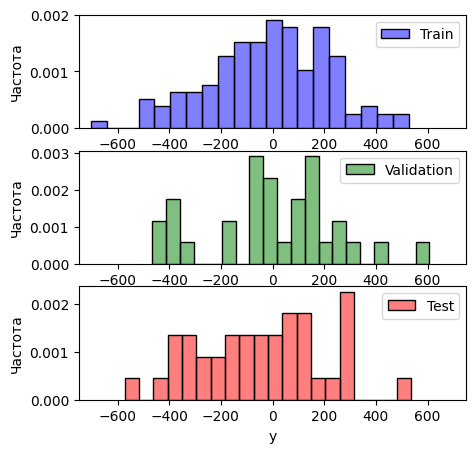

In [54]:
fig, axes = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(
    y_train, color='blue', label='Train', bins=20, alpha=0.5, stat='density', ax=axes[0]
)
axes[0].legend()
axes[0].set_xlabel('y')
axes[0].set_ylabel('Частота')
axes[0].set_xlim(-750, 750)

sns.histplot(
    y_val, color='green', label='Validation', bins=20, alpha=0.5, stat='density', ax=axes[1]
)
axes[1].legend()
axes[1].set_xlabel('y')
axes[1].set_ylabel('Частота')
axes[1].set_xlim(-750, 750)

sns.histplot(
    y_test, color='red', label='Test', bins=20, alpha=0.5, stat='density', ax=axes[2]
)
axes[2].legend()
axes[2].set_xlabel('y')
axes[2].set_ylabel('Частота')
axes[2].set_xlim(-750, 750)

plt.show()

In [57]:
# Обучаем модель LinearRegression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
# Предсказываем целевую метрику на валидационных данных
y_pred_val = lr_model.predict(X_val)

In [60]:
# Оцениваем качество модели lr_model
mse_lr_model = mean_squared_error(y_val, y_pred_val)
r2_lr_model = r2_score(y_val, y_pred_val)

print(f"LinearRegression → MSE: {mse_lr_model:.3f}, R2: {r2_lr_model:.3f}")

LinearRegression → MSE: 20064.504, R2: 0.672


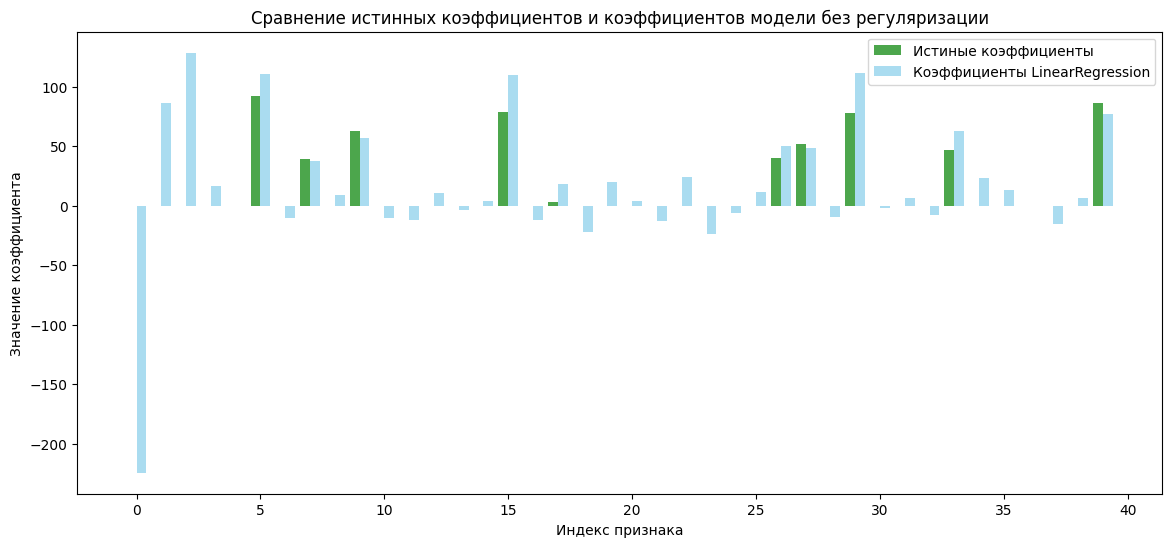

In [72]:
indices = np.arange(len(true_coefs))

plt.figure(figsize=(14, 6))
width = 0.4

plt.bar(
    indices - width / 2,
    true_coefs,
    width=width,
    label='Истиные коэффициенты',
    color='green',
    alpha=0.7
)

plt.bar(
    indices + width / 2,
    lr_model.coef_,
    width=width,
    label='Коэффициенты LinearRegression',
    color='skyblue',
    alpha=0.7    
)

plt.xlabel('Индекс признака')  
plt.ylabel('Значение коэффициента')  
plt.title('Сравнение истинных коэффициентов и коэффициентов модели без регуляризации') 
plt.legend() 
plt.show()